# Confronto Auto Elettriche vs Auto Ibride in Italia
### Autovetture per 1.000 autovetture circolanti — Dati ISTAT (comuni capoluogo di provincia)

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Caricamento e pulizia dati ──
# Il CSV ha intestazioni multi-livello; si salta la prima riga e si accede per posizione.
# col 3 = Territorio  |  col 6 = anno  |  col 7 = valore

def load_italia(path):
    df = pd.read_csv(path, encoding='utf-8-sig', header=None, skiprows=1)
    it = df[df[3] == 'Italia'][[6, 7]].copy()
    it.columns = ['Anno', 'Val']
    it['Anno'] = it['Anno'].astype(int)
    it['Val']  = pd.to_numeric(it['Val'], errors='coerce')
    return it.sort_values('Anno').reset_index(drop=True)

elettr = load_italia('../data/csv/auto_elettr_su_1000.csv')
ibride = load_italia('../data/csv/auto_ibride_su_1000.csv')

df = pd.merge(elettr, ibride, on='Anno', suffixes=('_Elettriche', '_Ibride'))
df[['Val_Elettriche', 'Val_Ibride']] = df[['Val_Elettriche', 'Val_Ibride']] / 10

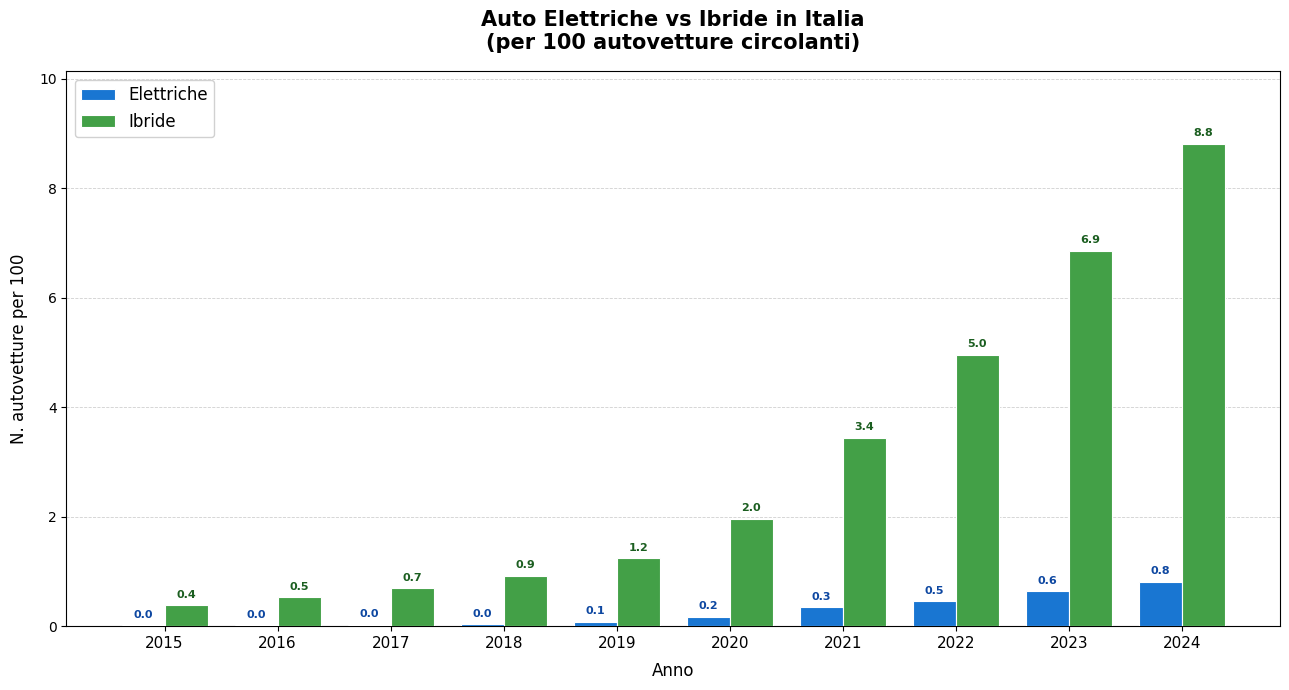

In [52]:
# ── Grafico a istogrammi affiancati ──
anni  = df['Anno'].astype(str).tolist()
val_e = df['Val_Elettriche'].tolist()
val_i = df['Val_Ibride'].tolist()

x     = np.arange(len(anni))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor("#FFFFFF")
ax.set_facecolor("#FFFFFF")

bars_e = ax.bar(x - width/2, val_e, width, label='Elettriche',
                color='#1976D2', edgecolor='white', linewidth=0.8, zorder=3)
bars_i = ax.bar(x + width/2, val_i, width, label='Ibride',
                color='#43A047', edgecolor='white', linewidth=0.8, zorder=3)

# Etichette valori
for bar, v in zip(bars_e, val_e):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1, f'{v:.1f}',
            ha='center', va='bottom', fontsize=8, color='#0D47A1', fontweight='bold')
for bar, v in zip(bars_i, val_i):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1, f'{v:.1f}',
            ha='center', va='bottom', fontsize=8, color='#1B5E20', fontweight='bold')

# Assi e griglia
ax.set_xticks(x)
ax.set_xticklabels(anni, fontsize=11)
ax.set_ylim(0, max(max(val_e), max(val_i)) * 1.15)   # <-- aggiunto
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))  # <-- da 10 a 5 per più riferimenti
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))  # <-- aggiunto: valori interi
ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.6, zorder=0)

# Titoli
ax.set_title('Auto Elettriche vs Ibride in Italia\n(per 100 autovetture circolanti)',
             fontsize=15, fontweight='bold', pad=16)
ax.set_xlabel('Anno', fontsize=12, labelpad=8)
ax.set_ylabel('N. autovetture per 100', fontsize=12, labelpad=8)
ax.legend(fontsize=12, framealpha=0.9, loc='upper left')

plt.tight_layout()
plt.show()

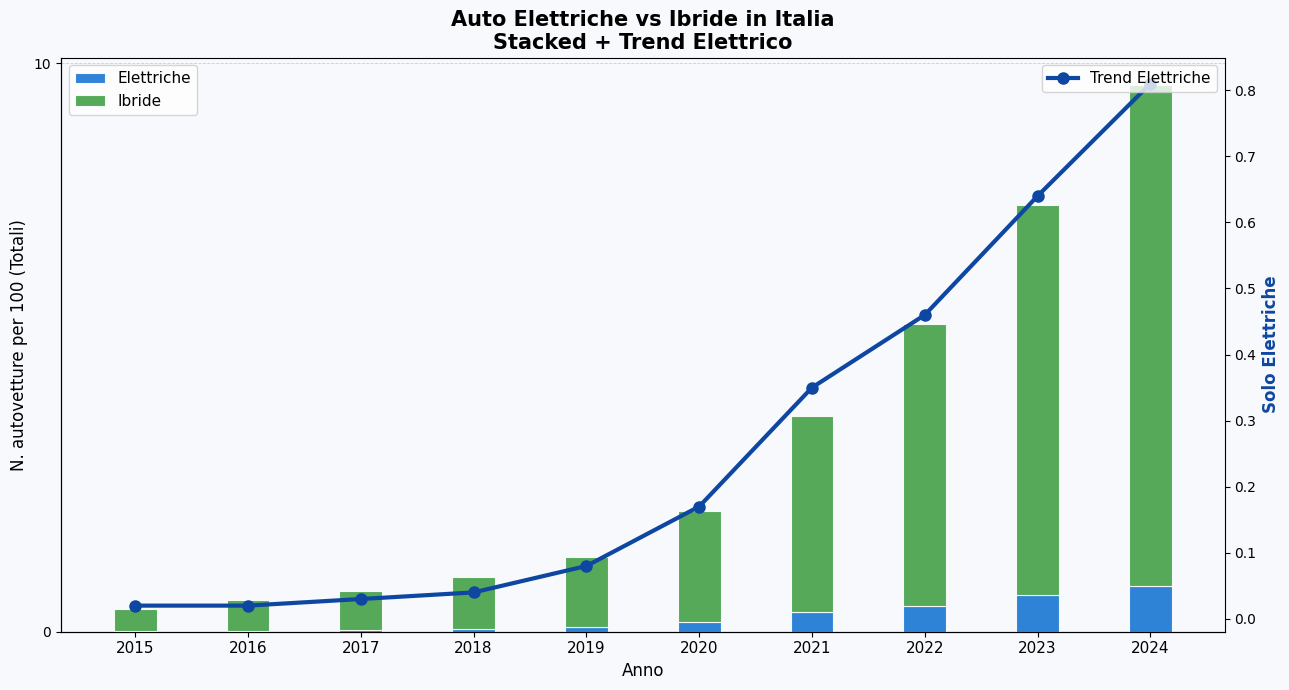

In [53]:
# VARIANTE 1A: BARRE STACKED + TREND ELETTRICO
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#F7F9FC')
ax.set_facecolor('#F7F9FC')

# Stacked bars
bottom = np.zeros(len(anni))
bars_e = ax.bar(x, val_e, width, label='Elettriche', bottom=bottom,
                color='#1976D2', edgecolor='white', linewidth=0.8, alpha=0.9, zorder=3)
bottom += val_e
bars_i = ax.bar(x, val_i, width, label='Ibride', bottom=bottom,
                color='#43A047', edgecolor='white', linewidth=0.8, alpha=0.9, zorder=3)

# Linea trend elettrico
ax2 = ax.twinx()
ax2.plot(x, val_e, 'o-', color='#0D47A1', linewidth=3, markersize=8, 
         label='Trend Elettriche', zorder=5)
ax2.set_ylabel('Solo Elettriche', color='#0D47A1', fontsize=12, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(anni, fontsize=11)
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.6)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_title('Auto Elettriche vs Ibride in Italia\nStacked + Trend Elettrico', fontsize=15, fontweight='bold')
ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('N. autovetture per 100 (Totali)', fontsize=12)
ax.legend(loc='upper left', fontsize=11)
ax2.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()


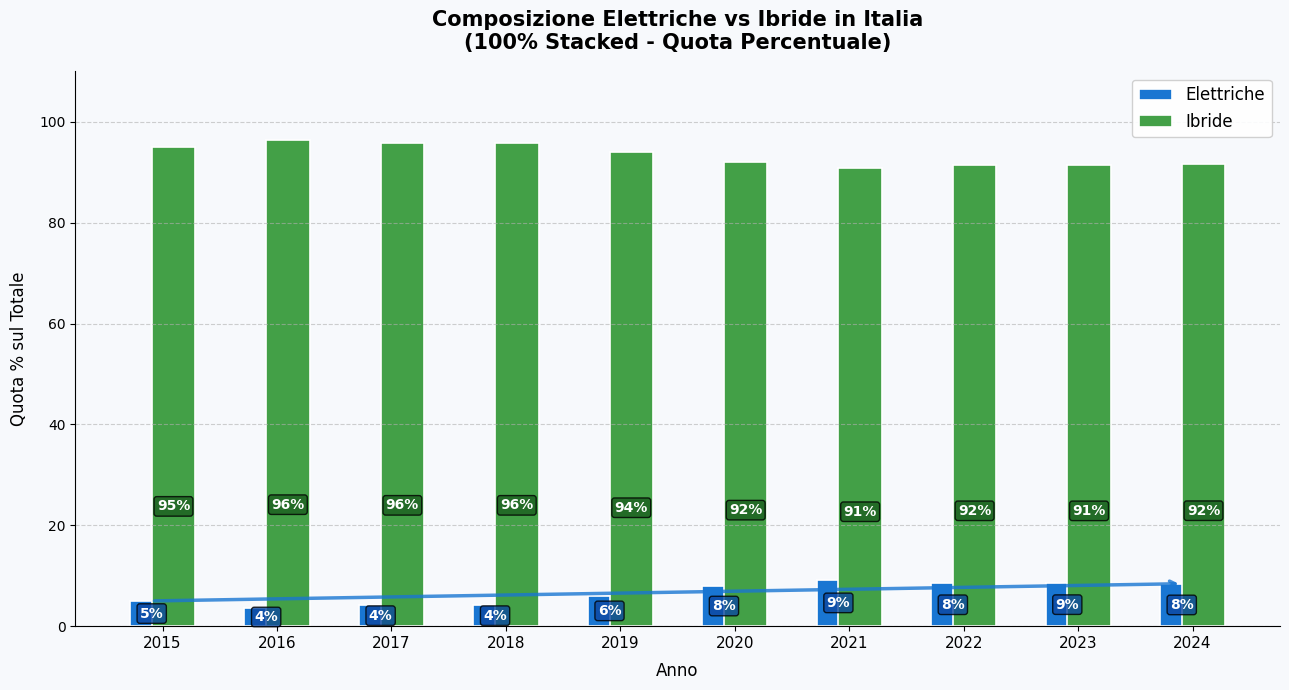

In [54]:
# VARIANTE 1B: 100% STACKED - ETICHETTE VERDI PIÙ INTERNE
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

totals = np.array(val_e) + np.array(val_i)
percent_e = (np.array(val_e) / totals) * 100
percent_i = (np.array(val_i) / totals) * 100

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#F7F9FC')
ax.set_facecolor('#F7F9FC')

bars_e = ax.bar(x, percent_e, width, label='Elettriche', 
                color='#1976D2', edgecolor='white', linewidth=1.2)
bars_i = ax.bar(x + width/2, percent_i, width, label='Ibride',
                color='#43A047', edgecolor='white', linewidth=1.2)

# ETICHETTE ELETTRICHE (blu) - centro barre
for i, e_pct in enumerate(percent_e):
    ax.text(x[i], e_pct/2, f'{e_pct:.0f}%', 
            ha='center', va='center', fontsize=10, fontweight='bold', 
            color='white', bbox=dict(boxstyle="round,pad=0.2", facecolor='#0D47A1', alpha=0.8))

# ETICHETTE IBRIDE (verde) - PIÙ INTERNE (a 25% dall'inizio barra)
for i, i_pct in enumerate(percent_i):
    ax.text(x[i] + width/2, i_pct * 0.25, f'{i_pct:.0f}%',  # ← 25% invece di 50%
            ha='center', va='center', fontsize=10, fontweight='bold', 
            color='white', bbox=dict(boxstyle="round,pad=0.2", facecolor='#1B5E20', alpha=0.8))

# Freccia crescita (opzionale)
if val_e[-1] > val_e[0]:
    ax.annotate('', xy=(len(anni)-1, percent_e[-1]), xytext=(0, percent_e[0]),
                arrowprops=dict(arrowstyle='->', lw=2.5, color='#1976D2', alpha=0.8))

ax.set_ylim(0, 110)
ax.set_xticks(x + width/4)
ax.set_xticklabels(anni, fontsize=11)
ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
ax.grid(axis='y', linestyle='--', alpha=0.6)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_title('Composizione Elettriche vs Ibride in Italia\n(100% Stacked - Quota Percentuale)', 
             fontsize=15, fontweight='bold', pad=16)
ax.set_xlabel('Anno', fontsize=12, labelpad=8)
ax.set_ylabel('Quota % sul Totale', fontsize=12, labelpad=8)
ax.legend(fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.show()

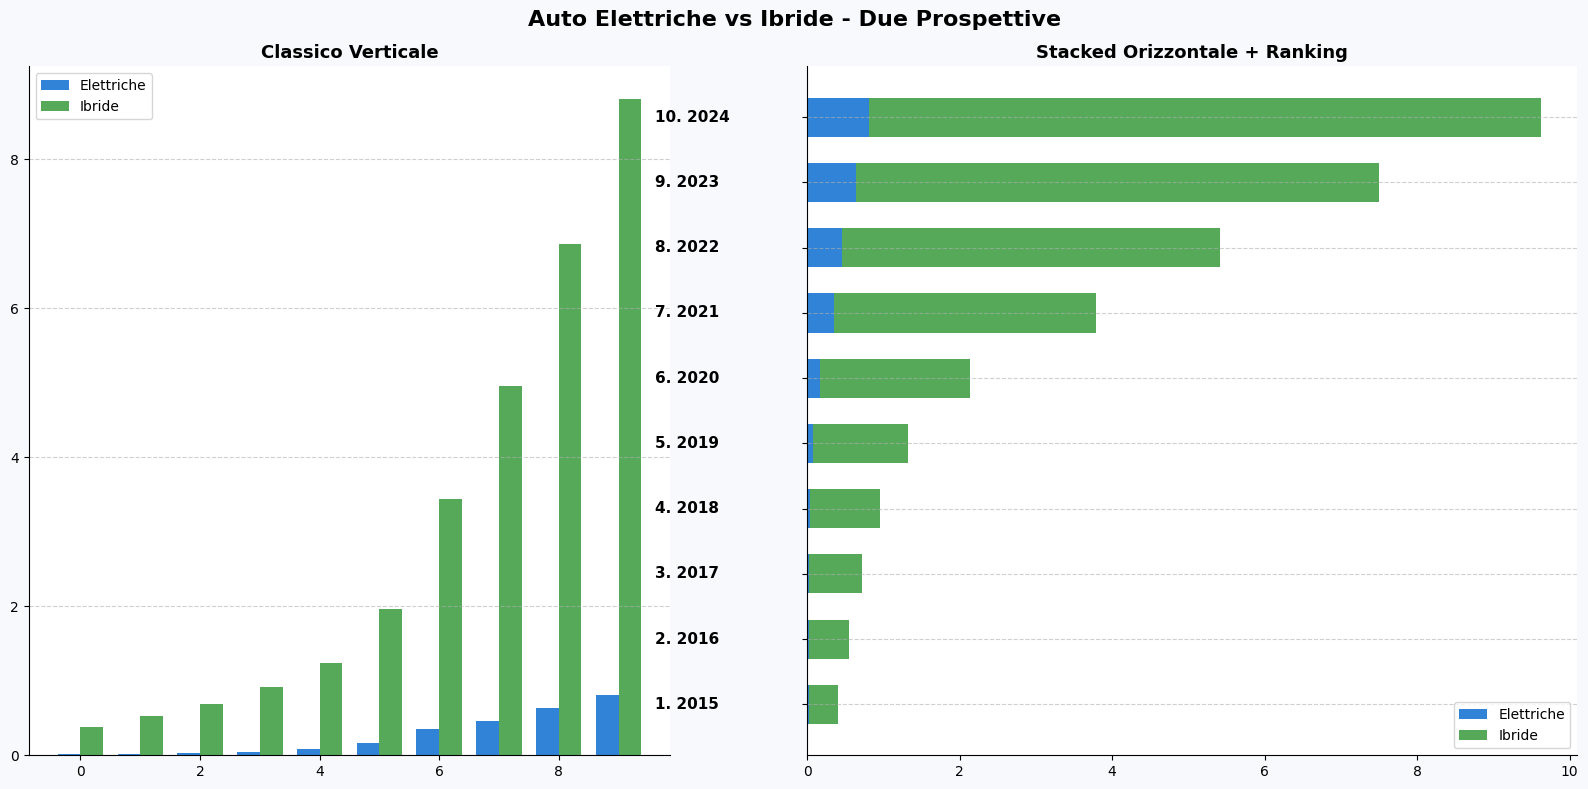

In [55]:
# VARIANTE 1C: BARRE ORIZZONTALI + RANKING
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [1, 1.2]})
fig.patch.set_facecolor('#F7F9FC')

# Sinistra: Verticale classico
bars_e1 = ax1.bar(x - width/2, val_e, width, label='Elettriche', color='#1976D2', alpha=0.9)
bars_i1 = ax1.bar(x + width/2, val_i, width, label='Ibride', color='#43A047', alpha=0.9)
ax1.set_title('Classico Verticale', fontweight='bold', fontsize=13)
ax1.legend(fontsize=10)

# Destra: Orizzontale con ranking
y_pos = np.arange(len(anni))
width_h = 0.6
bars_eh = ax2.barh(y_pos, val_e, width_h, label='Elettriche', color='#1976D2', alpha=0.9)
bars_ih = ax2.barh(y_pos, val_i, width_h, left=val_e, label='Ibride', color='#43A047', alpha=0.9)

# Ranking numerico
for i, anno in enumerate(anni):
    ax2.text(-2, i, f'{i+1}. {anno}', va='center', fontweight='bold', fontsize=11)

ax2.set_yticks(y_pos)
ax2.set_yticklabels('')
ax2.set_title('Stacked Orizzontale + Ranking', fontweight='bold', fontsize=13)
ax2.legend(fontsize=10)

plt.suptitle('Auto Elettriche vs Ibride - Due Prospettive', fontsize=16, fontweight='bold')
for ax in [ax1, ax2]:
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


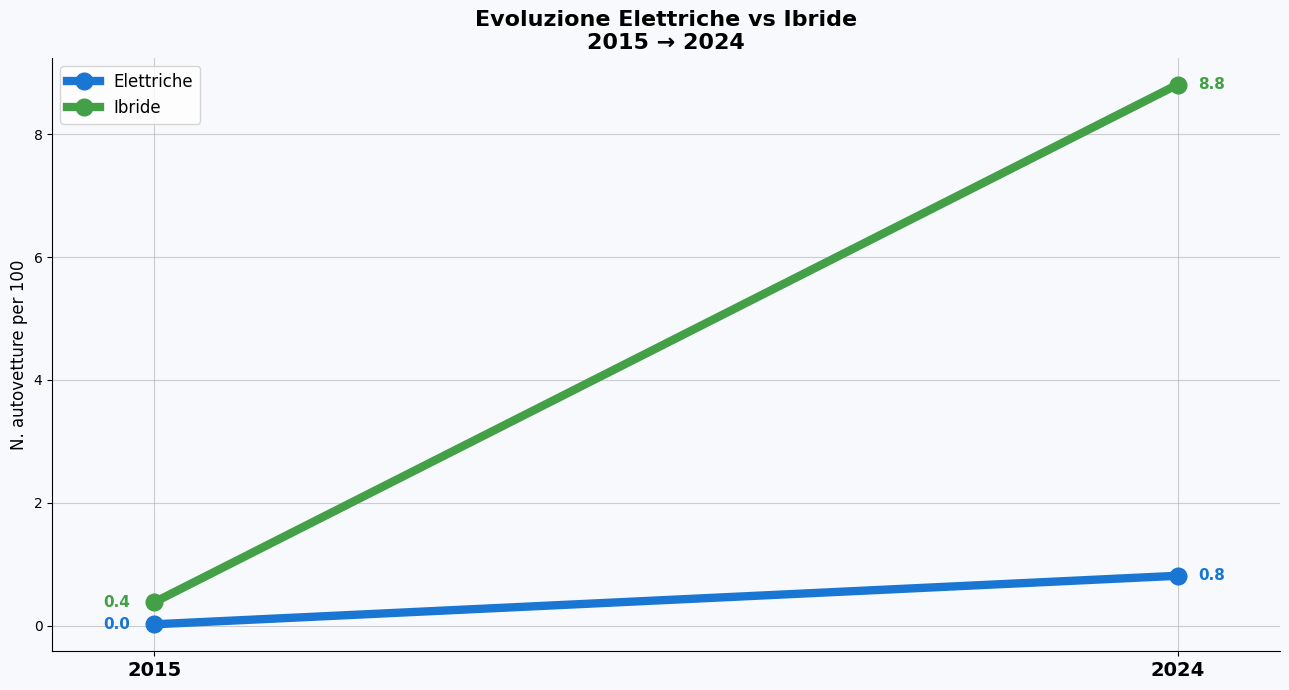

In [56]:
# VARIANTE 1D: SLOPE CHART - Evoluzione 2019→2025
first_year, last_year = min(anni), max(anni)
idx_first = anni.index(first_year)
idx_last = anni.index(last_year)

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#F7F9FC')
ax.set_facecolor('#F7F9FC')

# Linee di pendenza
ax.plot([0, 1], [val_e[idx_first], val_e[idx_last]], 'o-', 
        linewidth=6, markersize=12, color='#1976D2', label='Elettriche', zorder=4)
ax.plot([0, 1], [val_i[idx_first], val_i[idx_last]], 'o-', 
        linewidth=6, markersize=12, color='#43A047', label='Ibride', zorder=4)

# Etichette estremi
for i, (v_start, v_end, color, label) in enumerate([
    (val_e[idx_first], val_e[idx_last], '#1976D2', 'Elettriche'),
    (val_i[idx_first], val_i[idx_last], '#43A047', 'Ibride')
]):
    ax.text(-0.05, v_start, f'{v_start:.1f}', va='center', fontweight='bold', 
            color=color, fontsize=11)
    ax.text(1.02, v_end, f'{v_end:.1f}', va='center', fontweight='bold', 
            color=color, fontsize=11)

ax.set_xlim(-0.1, 1.1)
ax.set_xticks([0, 1])
ax.set_xticklabels([first_year, last_year], fontsize=14, fontweight='bold')
ax.set_ylabel('N. autovetture per 100', fontsize=12)
ax.grid(True, alpha=0.6)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_title(f'Evoluzione Elettriche vs Ibride\n{first_year} → {last_year}', 
             fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')

plt.tight_layout()
plt.show()
